# NLP Group 08 Project

# NLP-Based Customer Support Ticket Classification System

### Notebook 1:  Data Collection and Exploration

**Course:** 7500 - Natural Language Processing  
**Group:** 08

---

## Objective

The purpose of this notebook is to perform an initial exploration of the customer support ticket dataset. This includes loading the dataset, examining its structure, identifying the available features, checking for missing values, and exploring the distribution of ticket categories. The insights gained from this analysis will guide the preprocessing and model development stages of the project.

## Pipeline Overview

This notebook completes the Data Collection phase of the NLP pipeline by:

- Importing the required libraries.
- Loading the customer support ticket dataset.
- Examining the dataset structure.
- Checking data types and missing values.
- Exploring ticket categories and priorities.
- Identifying the input feature and target variable for the classification model.

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

**Load Data**

In [4]:
df = pd.read_parquet("../data/nlp_dataset.parquet")

df.head()

,Customer Email,Product Purchased,Ticket Type,Ticket Subject,Combined Text,Ticket Priority
0,carrollallison@example.com,gopro hero,technical issue,product setup,i'm having an issue with the gopro hero. pleas...,critical
1,clarkeashley@example.com,lg smart tv,technical issue,peripheral compatibility,i'm having an issue with the lg smart tv. plea...,critical
2,gonzalestracy@example.com,dell xps,technical issue,network problem,i'm facing a problem with my dell xps. the del...,low
3,bradleyolson@example.org,microsoft office,billing inquiry,account access,i'm having an issue with the microsoft office....,low
4,bradleymark@example.com,autodesk autocad,billing inquiry,data loss,i'm having an issue with the autodesk autocad....,low


## Dataset Overview

**Dataset Shape**

In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 8469
Columns: 6


**Display Column Names**

In [6]:
print(df.columns.tolist())

['Customer Email', 'Product Purchased', 'Ticket Type', 'Ticket Subject', 'Combined Text', 'Ticket Priority']


**Dataset Info**

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Customer Email     8469 non-null   object
 1   Product Purchased  8469 non-null   object
 2   Ticket Type        8469 non-null   object
 3   Ticket Subject     8469 non-null   object
 4   Combined Text      8469 non-null   object
 5   Ticket Priority    8469 non-null   object
dtypes: object(6)
memory usage: 397.1+ KB


**Missing Values**

In [8]:
df.isnull().sum()

Customer Email       0
Product Purchased    0
Ticket Type          0
Ticket Subject       0
Combined Text        0
Ticket Priority      0
dtype: int64

**Preview Random Rows**

In [9]:
df.sample(5)

,Customer Email,Product Purchased,Ticket Type,Ticket Subject,Combined Text,Ticket Priority
3779,wgallegos@example.net,sony 4k hdr tv,technical issue,refund request,i'm having an issue with the sony 4k hdr tv. p...,low
7195,walter21@example.com,philips hue lights,cancellation request,product setup,i'm having an issue with the philips hue light...,low
4224,olarson@example.net,dell xps,billing inquiry,account access,i'm having an issue with the dell xps. please ...,medium
1831,drodriguez@example.net,samsung galaxy,technical issue,battery life,my samsung galaxy is making strange noises and...,low
4532,itaylor@example.org,sony 4k hdr tv,product inquiry,network problem,i'm encountering a software bug in the sony 4k...,high


## Exploratory Data Analysis

****Explore the Dataset****

Display Column Names

In [10]:
print(df.columns.tolist())

['Customer Email', 'Product Purchased', 'Ticket Type', 'Ticket Subject', 'Combined Text', 'Ticket Priority']


*Dataset Statistics*

In [11]:
print(f"Number of tickets: {len(df)}")
print(f"Number of features: {df.shape[1]}")

Number of tickets: 8469
Number of features: 6


**Ticket Type Distribution**

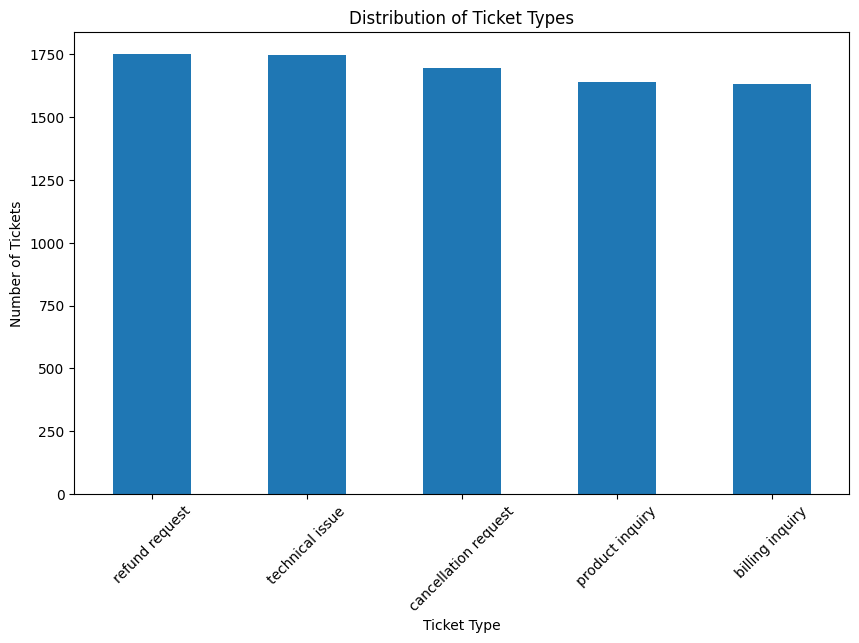

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

df["Ticket Type"].value_counts().plot(kind="bar")

plt.title("Distribution of Ticket Types")
plt.xlabel("Ticket Type")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45)

plt.show()

**Ticket Priority Distribution**

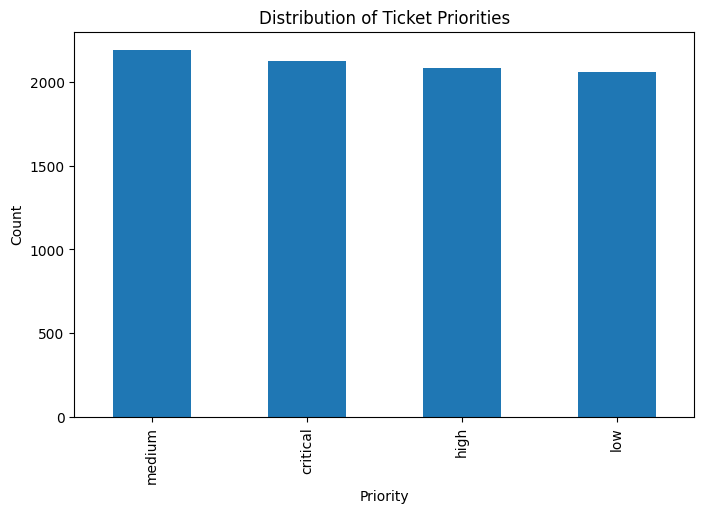

In [13]:
plt.figure(figsize=(8,5))

df["Ticket Priority"].value_counts().plot(kind="bar")

plt.title("Distribution of Ticket Priorities")
plt.xlabel("Priority")
plt.ylabel("Count")

plt.show()

**Number of Unique Classes**

In [14]:
print("Unique Ticket Types:")
print(df["Ticket Type"].unique())

print("\nNumber of Classes:", df["Ticket Type"].nunique())

Unique Ticket Types:
['technical issue' 'billing inquiry' 'cancellation request'
 'product inquiry' 'refund request']

Number of Classes: 5


**Combined Text Length**

In [15]:
df["Text Length"] = df["Combined Text"].str.len()

df["Text Length"].describe()

count    8469.000000
mean      306.791593
std        45.183917
min       154.000000
25%       287.000000
50%       314.000000
75%       336.000000
max       429.000000
Name: Text Length, dtype: float64

**Distribution of Text Lengths**

0    294
1    285
2    287
3    305
4    355
Name: Text Length, dtype: int64
count    8469.000000
mean      306.791593
std        45.183917
min       154.000000
25%       287.000000
50%       314.000000
75%       336.000000
max       429.000000
Name: Text Length, dtype: float64


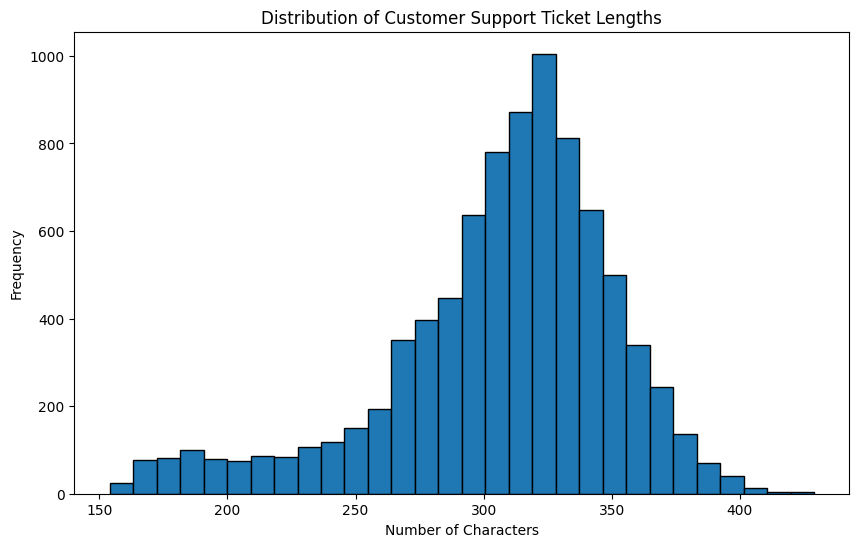

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# Make sure Text Length exists and is numeric
df["Text Length"] = df["Combined Text"].astype(str).apply(len)

print(df["Text Length"].head())
print(df["Text Length"].describe())

# Plot
df["Text Length"].plot(kind="hist", bins=30, figsize=(10,6), edgecolor="black")

plt.title("Distribution of Customer Support Ticket Lengths")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.show()

## Observations

- The dataset contains 8,469 customer support tickets.
- There are six features describing each support request.
- No missing values were identified.
- The primary text feature is **Combined Text**.
- The target variable for classification is **Ticket Type**.
- The dataset is ready for preprocessing